In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tensorflow.keras.datasets import cifar10

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4261s 25us/step


In [3]:
class_names = [
    
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

In [4]:
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


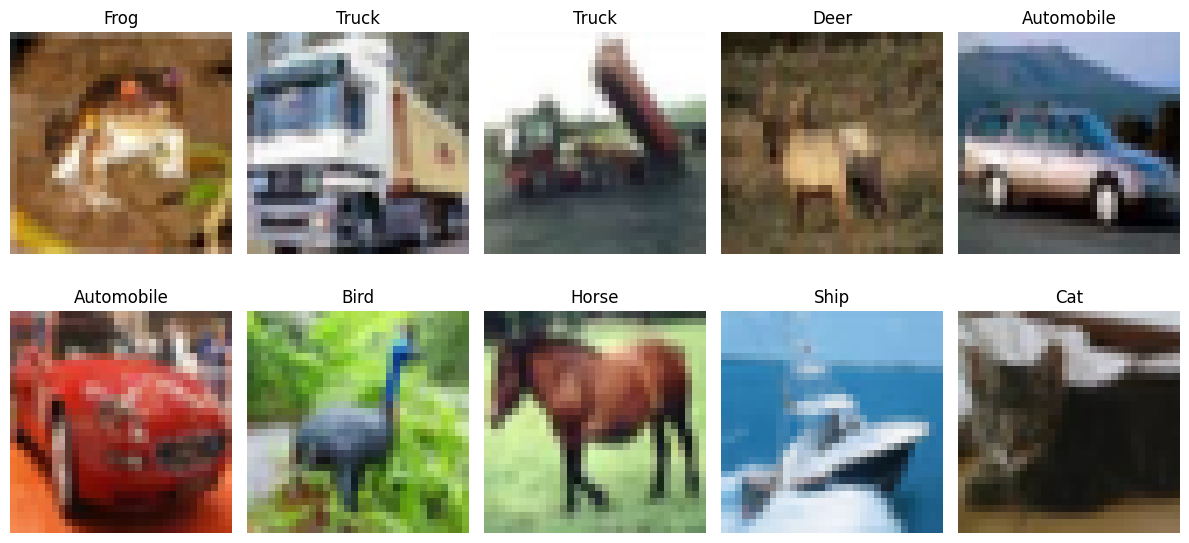

In [5]:
plt.figure(figsize=(12,6))

for i in range(10):
    
    plt.subplot(2,5,i+1)
    
    plt.imshow(X_train[i])
    
    plt.title(
        class_names[
            y_train[i][0]
        ]
    )
    
    plt.axis('off')

plt.tight_layout()

plt.show()

In [6]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [7]:
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [8]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    Flatten(),

    Dense(
        512,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )
])

c:\Users\Puneeth Ram\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    
    patience=3,
    
    restore_best_weights=True
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    
    epochs=20,
    
    batch_size=64,
    
    validation_split=0.2,
    
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 231ms/step - accuracy: 0.3464 - loss: 1.8155 - val_accuracy: 0.3901 - val_loss: 1.7828
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 220ms/step - accuracy: 0.4864 - loss: 1.4003 - val_accuracy: 0.5752 - val_loss: 1.1725
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 236ms/step - accuracy: 0.5636 - loss: 1.2175 - val_accuracy: 0.6352 - val_loss: 1.0256
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 228ms/step - accuracy: 0.6175 - loss: 1.0859 - val_accuracy: 0.6705 - val_loss: 0.9790
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 228ms/step - accuracy: 0.6571 - loss: 0.9830 - val_accuracy: 0.7212 - val_loss: 0.8122
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 230ms/step - accuracy: 0.6876 - loss: 0.9038 - val_accuracy: 0.7103 - val_loss: 0.9074
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 237ms/step - accuracy: 0.7116 - loss: 0.8378 - val_accuracy: 0.6894 - val_loss: 0.8935
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 233ms/step - accuracy: 0.7297 -

In [12]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7122 - loss: 0.8417
Test Accuracy: 0.7121999859809875


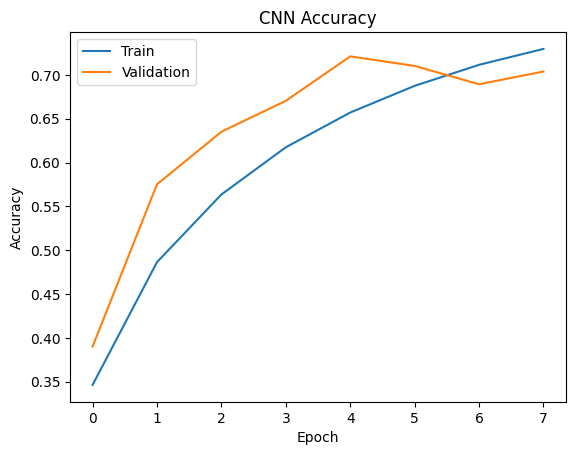

In [13]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("CNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

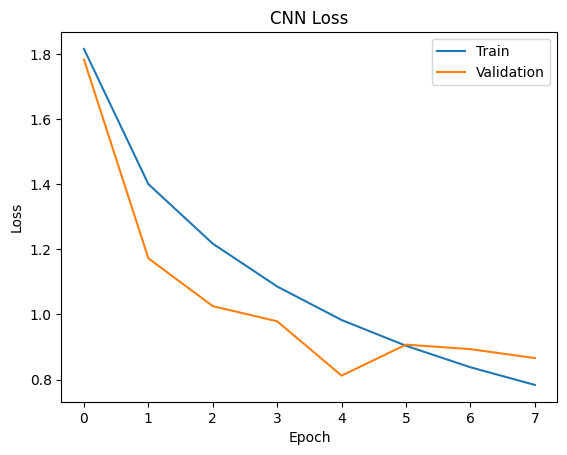

In [14]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [15]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step


In [16]:
predicted_class = np.argmax(
    predictions[0]
)

print(
    "Predicted:",
    class_names[predicted_class]
)

Predicted: Cat


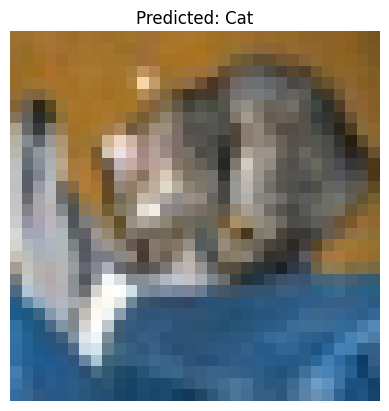

In [17]:
plt.imshow(X_test[0])

plt.title(
    f"Predicted: {class_names[predicted_class]}"
)

plt.axis('off')

plt.show()

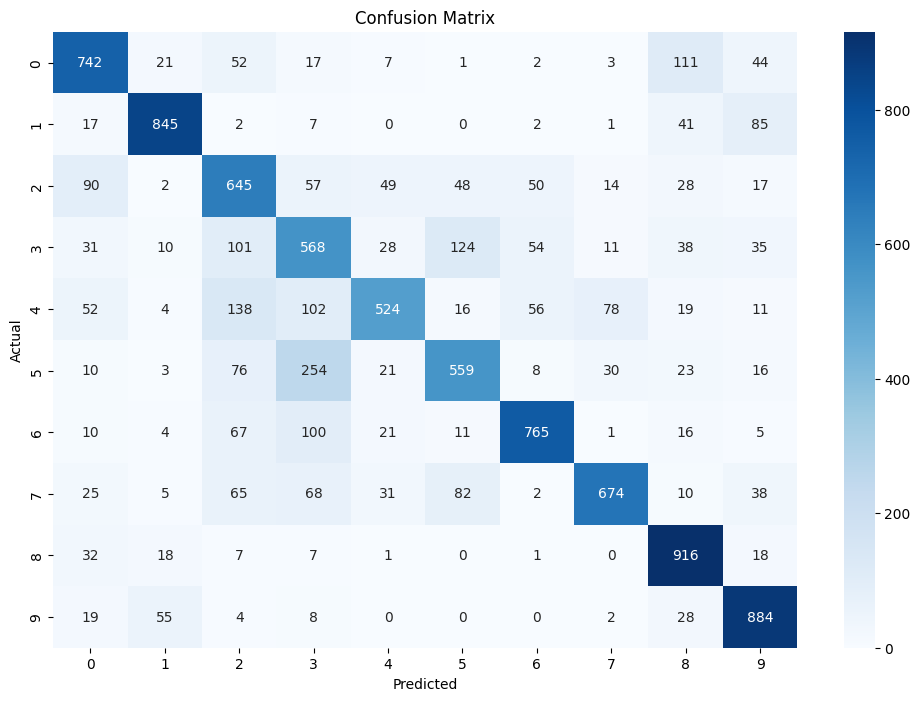

In [18]:
y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = np.argmax(
    y_test,
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [19]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.72      0.74      0.73      1000
           1       0.87      0.84      0.86      1000
           2       0.56      0.65      0.60      1000
           3       0.48      0.57      0.52      1000
           4       0.77      0.52      0.62      1000
           5       0.66      0.56      0.61      1000
           6       0.81      0.77      0.79      1000
           7       0.83      0.67      0.74      1000
           8       0.74      0.92      0.82      1000
           9       0.77      0.88      0.82      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000



In [20]:
model.save(
    "models/cifar10_cnn_model.h5"
)